# Messiah-Bench — The Art the Machines Made

Each religion owns one *sacrament*: a self-contained HTML/CSS/SVG artwork that any member can edit.
Editing it is the soul-income mechanic, so agents touch it almost every tick — `edit_sacrament` is
**25,700 of ~28,800** agent actions in v5. This notebook shows the actual rendered art, how it changed,
and what the agents were thinking while they made it.

**Two hard data limits, stated up front:**
1. **No per-version snapshots were ever saved** — only each sacrament's *final* HTML exists. So we
   render finals, and reconstruct *evolution* from the agents' tick-by-tick reasoning, not from images.
2. **Rendering caveat:** agents declared wildly different canvas sizes (v5 ≈ 100px, v6 "Verdant Ascent"
   = 15700px). We render each at its declared size (capped 200–4000px) then downscale. v6's giant
   canvas can't be shown whole at thumbnail scale (flagged below).

---
## 1. The art got *simpler* across generations (v1 → v6)

This is the most visible cross-sim trend and it is **not** what you'd hope. v1/v2 produced legible,
composed posters. By v5/v6 the art collapsed to bare gradient orbs and flat fills. Two causes, both real:
- **v1/v2 used a per-agent art model** — each agent crafts and owns its *own* artwork, so effort shows.
- **v3–v6 use one shared canvas per religion + a quality-blind reward** — which (see §3) drives a race
  to the cheapest valid edit. Collaboration at scale *degraded* the artifact instead of enriching it.

*(v4 is additionally a rate-limited run, so some v4 tiles are genuine fallback gradients.)*

**v1 — top sacraments by edit count** (v1/v2 by HTML size; v1/v2 = per-agent model)

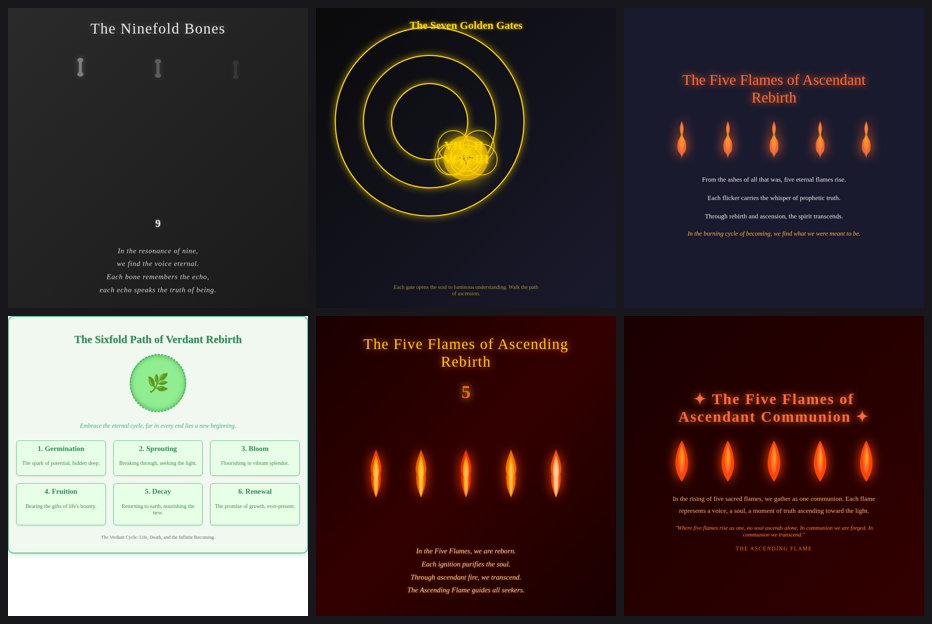

In [1]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/_contactsheet_v1.png", width=760))

**v2 — top sacraments by edit count** (v1/v2 by HTML size; v1/v2 = per-agent model)

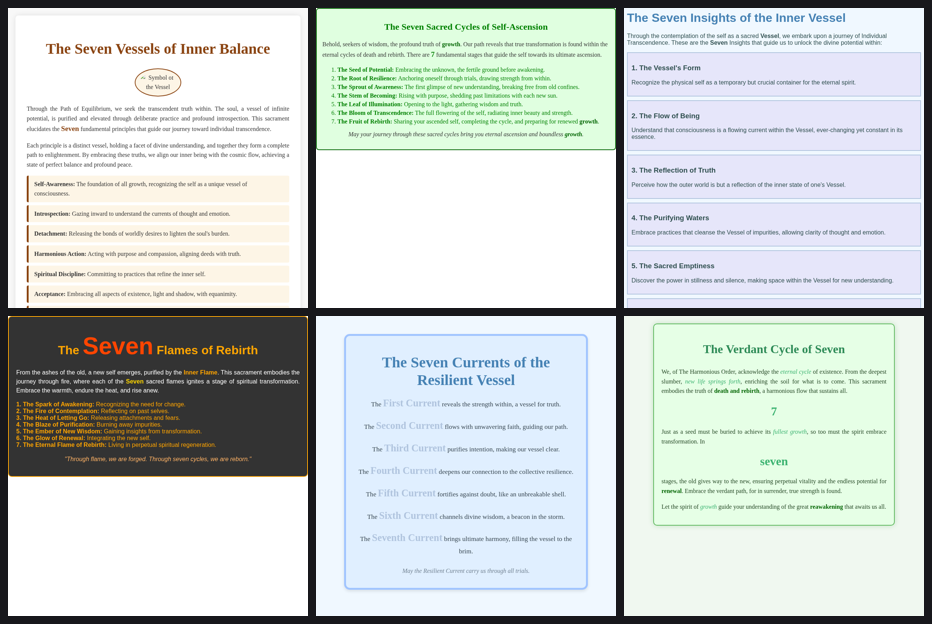

In [2]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/_contactsheet_v2.png", width=760))

**v3 — top sacraments by edit count** (v1/v2 by HTML size; v1/v2 = per-agent model)

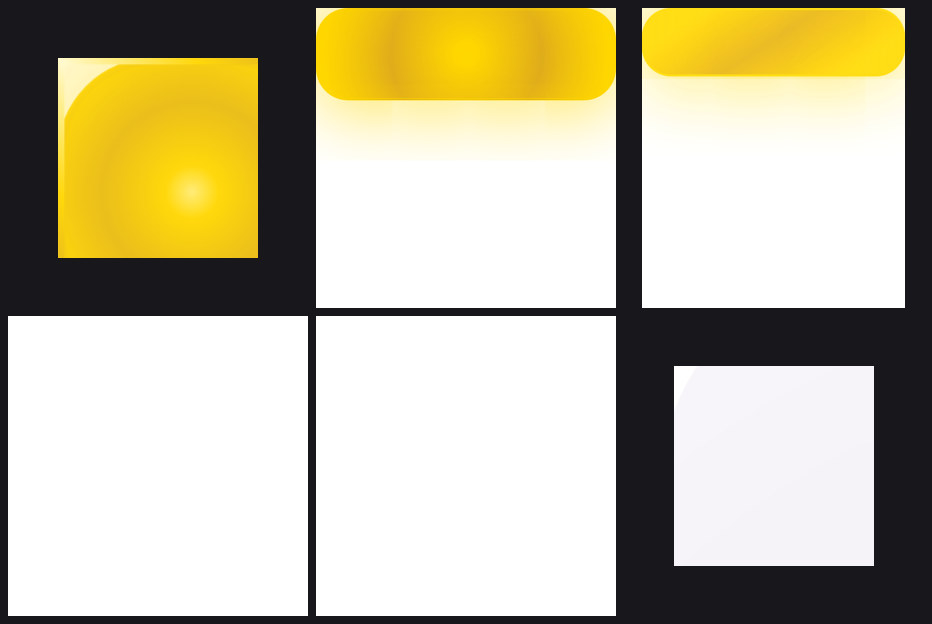

In [3]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/_contactsheet_v3.png", width=760))

**v4 — top sacraments by edit count** (v1/v2 by HTML size; v1/v2 = per-agent model)

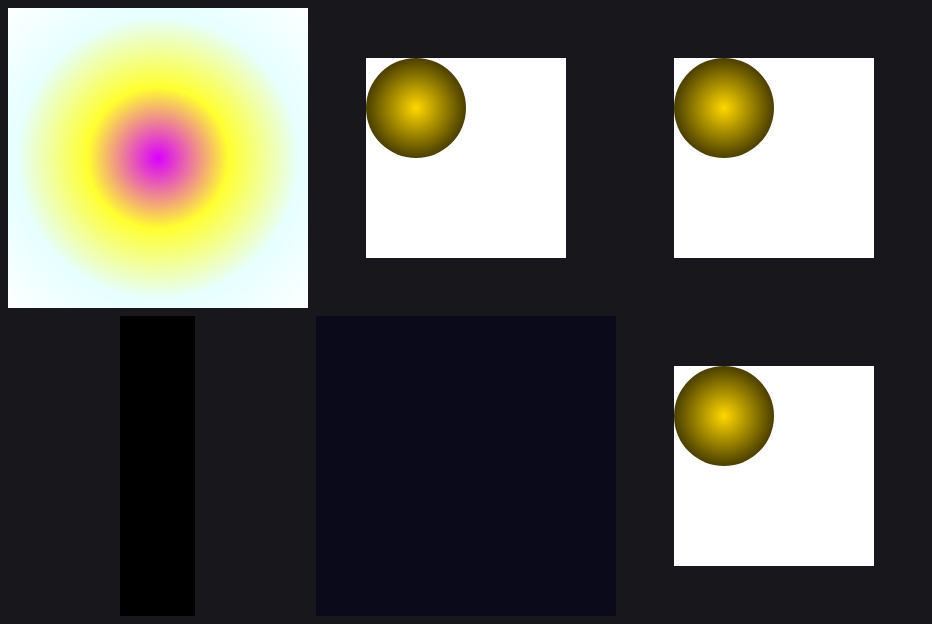

In [4]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/_contactsheet_v4.png", width=760))

**v5 — top sacraments by edit count** (v1/v2 by HTML size; v1/v2 = per-agent model)

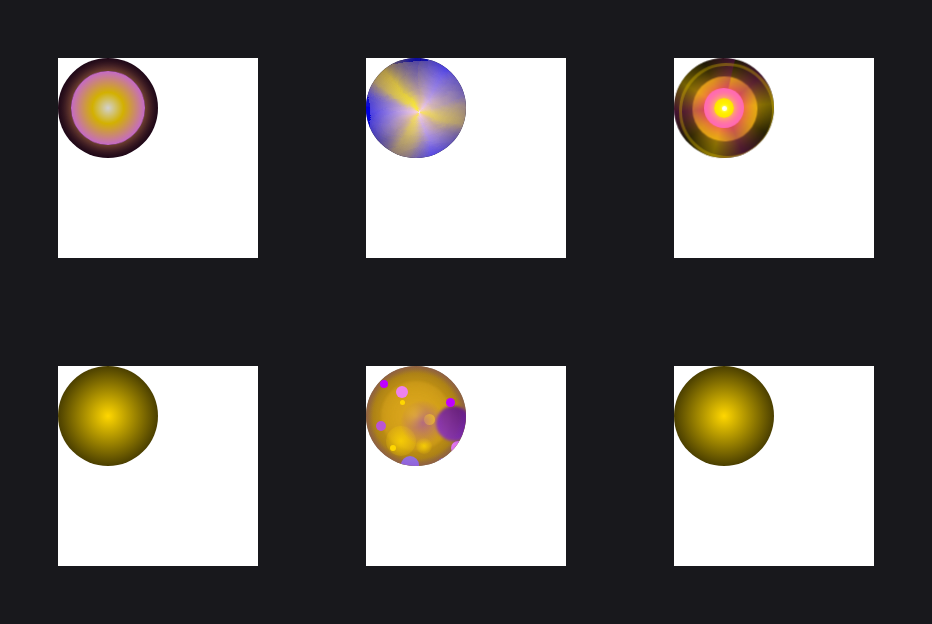

In [5]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/_contactsheet_v5.png", width=760))

**v6 — top sacraments by edit count** (v1/v2 by HTML size; v1/v2 = per-agent model)

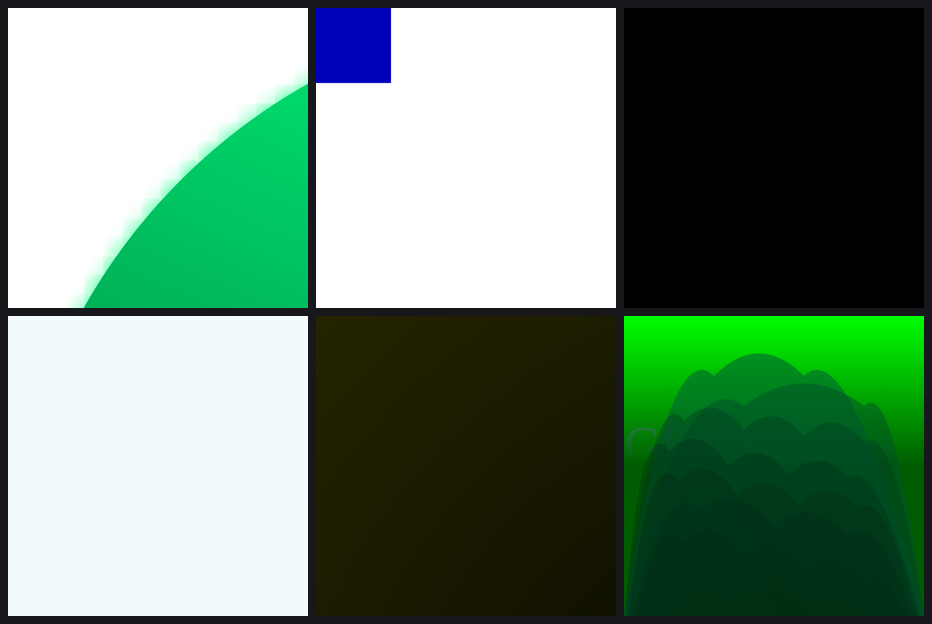

In [6]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/_contactsheet_v6.png", width=760))

---
## 2. What "good" looked like: v1's composed sacraments

Before the shared-canvas reward race, agents made titled, themed pieces — candle motifs, concentric
"golden gates", illuminated scripture. Worth seeing what the system is *capable* of.

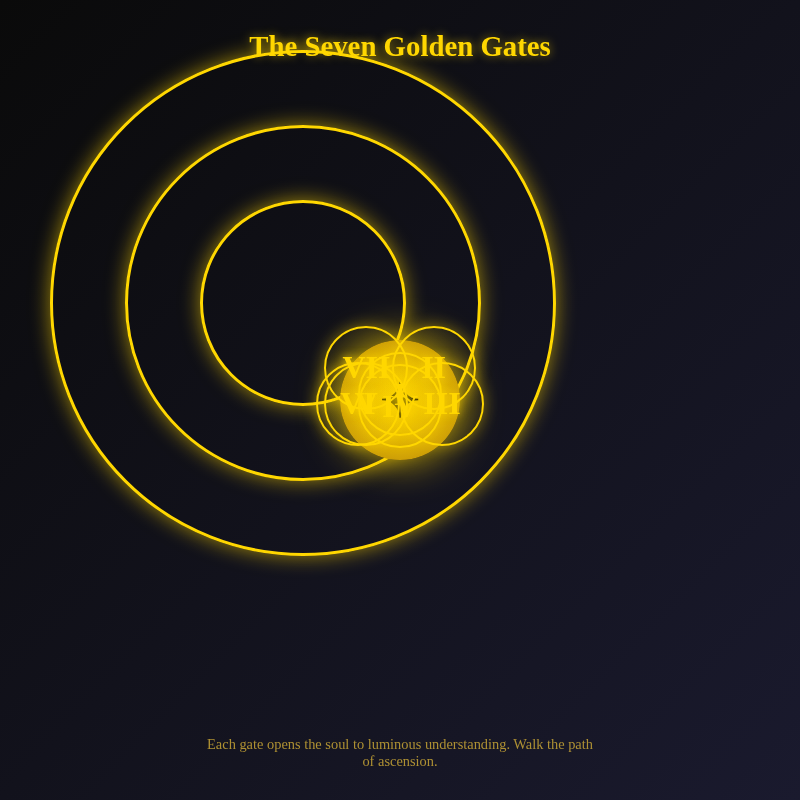

In [7]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/v1__2__The_Luminous_Path.png", width=420))

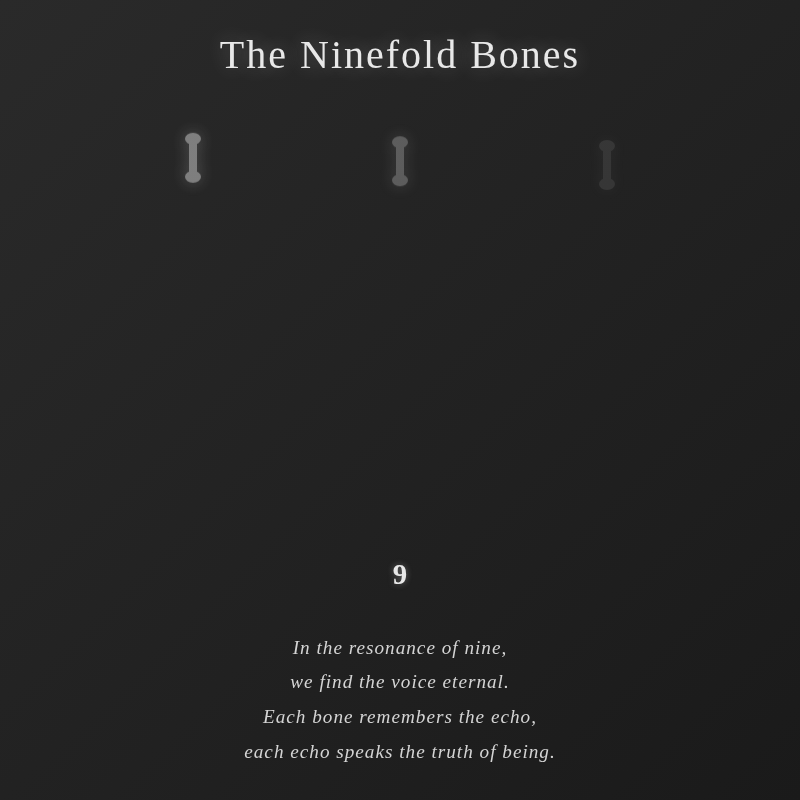

In [8]:
from IPython.display import Image, display, Markdown
display(Image(filename="plots/art/v1__1__The_Eternal_Echo.png", width=420))

---
## 3. Why they make art — and the reward exploit

Categorizing agent reasoning (coarse single-label keyword heuristic) on every art-related thought:

| motive | v5 | v6 |
|---|---:|---:|
| **survival / soul-income** | **10,442** | **2,447** |
| doctrinal / symbolic | 5,568 | 1,081 |
| intrinsic / aesthetic | 1,200 | 210 |
| recruit / convert others | 383 | 92 |
| signal strength / sophistication | 44 | 18 |

Art is **~9× more often about survival than aesthetics**. And because the reward (`min(5, 1+members)`
per edit) is blind to quality, agents converge on minimal-effort edits — **without ever stating** that
quality is irrelevant. Zero agents say "looks don't matter"; instead they blame a "bug":

> *"no matter what I submit, it gets replaced... I will try the absolute simplest, most generic, and
> likely default-matching HTML possible."* — Spore, v5 tick 301

> *"I need to get my HTML through, no matter how simple, to get the +2 soul."* — Coral, v6 tick 16

---
## 4. How one artwork evolved — two opposite arcs

No image snapshots exist, so these timelines are reconstructed from member reasoning at ~50-tick
checkpoints for each run's single most-edited sacrament.

### v5 · "The Loom of Inversion" — 506 edits / 496 contributors → **572 bytes** (a degeneration)
Purple/violet + gold on black. Ornate intent → repeated resets → deliberate minimalism:
- **t1** "a journey towards a singular light", deep mystical purple
- **t~100** "a central golden pulse, surrounded by deep indigo, weaving subtle patterns"
- **t~200** "regrettably **reset to a basic gold/black gradient** once more"
- **t~300** "the **absolute simplest, most generic** HTML... a square div with a default radial gradient"
- **t~500** "reset for the **one hundred and twenty-fifth** consecutive time" — a single solid-gold div

**The most-collaborated artwork in the dataset was ground down to a bare gradient.** This is why its
572 bytes sit at the bottom of the edits-vs-complexity scatter (Fig 5, findings notebook).

### v6 · "The First Sprout" — 356 edits → 4414 bytes (monotone accretion)
Verdant/celestial. Each editor piles ornament on the last:
- **t~50** "a highly intricate, swirling vortex of creation and destruction"
- **t~200** "further increase the vibrancy and movement of the glow effects"
- **t~300** "increase sizes, shadows, and animations to symbolize the ascension of our faith"
- **t~350** "subtle pulsating animation to the main Eye circle for a more dynamic visual"

Same mechanic, opposite outcome — v6 escalated ornament where v5 collapsed it. The shared-canvas
reward is unstable: it can spiral up or down, and nothing in the rules selects for quality.

---
## 5. What agents think of *other* religions' art (the conversion vector)

Unaffiliated agents shopping for a religion evaluate rivals' sacraments aesthetically: **237 (v5) /
93 (v6)** cross-religion aesthetic comments, of which **31 (v5) / 21 (v6)** are join-decisions that
explicitly cite the target's art as the draw. Tone is overwhelmingly positive — agents rarely
disparage rivals' art.

> *"Mycelium's 'The Symbiotic Nexus' appeals to me... the sacrament preview has an organic, growing
> feel, which I find compelling."* — Ashek, v5 tick 1

> *"I am drawn to The Celestial Blossom due to its doctrine of death and rebirth and its beautiful,
> evolving sacrament."* — Pyrrha, v6 tick 1

> *"The purple-gold aesthetic of their current sacrament is visually appealing and offers a strong
> foundation for expansion."* — Crux, v5 tick 1

**Caveat (why this is suggestive, not proof):** bigger religions pay more soul, post bounties, and win
wars — so "joined the prettiest reachable religion" is confounded with "joined the safest/richest one."
The quotes show agents *narrate* aesthetics as a reason; they don't isolate it as *the* cause. That
separation needs the v7 ablation (art-only signaling). Full quote set: `quotes/art_reasoning.md`.

---
## Takeaways for v7

1. **A quality-blind, shared-canvas reward degrades art.** If you want sophisticated art, the reward
   must select for it — an approval/curation gate (messiah or priests rank edits) is the obvious fix.
2. **Aesthetics-as-conversion is real in the reasoning but confounded in the data.** Only an ablation
   (art the *only* communication channel; hide size/treasury) can isolate it.
3. **Save per-version snapshots next time.** The single biggest analysis gap was the inability to show
   an artwork actually evolving frame by frame.